# 04. Tag 分布分析（分类先验 & 兴趣主题池）

> 对应 `analysis_plan.md` §2.4。

## 目的

1. **tag_lv3 结构解析**：从 §2.2 抽样已知 `tag_lv3` 是 `一级-二级-三级` 用连字符分隔的三段结构，例如 `游戏娱乐-游戏解说-传奇游戏解说`。拆分后按每层看词表大小、top-K、层级发散度。
2. **每 domain × 每层的 top-100 tag** —— 直接给到"兴趣演化任务"的题目采样池 & 懂用户任务的类别 hint。
3. **Tag ↔ SID 关联性**（**最核心分析**）：把 `Pid2Tag` 和 `Pid2Sid` 通过 pid join，算 `H(s_a | tag_lv1)` / `H(s_a | tag_lv3)` 与无条件熵 `H(s_a)` 对比。**IG 越大 → tag 越能强预测 SID → "tag → SID"任务越容易学，同时也说明 SID 已经隐含了品类信息**。
4. **每个 lv3 tag 找 top-K 最集中的 s_a 桶** —— 可直接给到 constrained decoding 里的 tag-conditioned s_a mask（比 §2.1.3 的 domain-conditioned 还要精细）。

## 输入 / 输出

**输入**：
- `dataset_rec_all/data/OneReason_Pid2Tag/*.parquet`（5.4M 行, 60MB —— 一次全量装入内存）
- `dataset_rec_all/data/OneReason_Pid2Sid/*.parquet` —— 只读 pid & sid_three, 用于 join

**输出**（`analysis/outputs/tag/`）：
- `tag_hierarchy_stats.csv` —— 每 domain 的 lv1/lv2/lv3 unique 数、发散度
- `top100_lv1_{domain}.csv` / `top100_lv3_{domain}.csv`
- `tag_sid_mutual_info.csv` —— 每 domain × 每层的 IG_tag→s_a
- `tag_lv3_top_sa_{domain}.csv` —— 每个 lv3 tag 最集中的 top-3 s_a 桶
- 相应的 png

In [10]:
# ============ 配置 & imports ============
import os, pickle, time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# ---- macOS 中文显示修复：不然 lv1 tag 名会显示成 tofu 方块 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Songti SC', 'STHeiti', 'Hiragino Sans GB', 'PingFang SC', 'Heiti SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
PID2TAG_DIR  = PROJECT_ROOT / 'dataset_rec_all' / 'data' / 'OneReason_Pid2Tag'
PID2SID_DIR  = PROJECT_ROOT / 'dataset_rec_all' / 'data' / 'OneReason_Pid2Sid'
OUT_DIR      = PROJECT_ROOT / 'analysis' / 'outputs' / 'tag'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TAG = OUT_DIR / '_tag_cache.pkl'
CACHE_JOIN = OUT_DIR / '_join_cache.pkl'

USE_CACHE = True

print('Pid2Tag dir :', PID2TAG_DIR)
print('Pid2Sid dir :', PID2SID_DIR)
print('Output dir  :', OUT_DIR)

Pid2Tag dir : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Tag
Pid2Sid dir : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Sid
Output dir  : /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/tag


## 步骤 1：全量加载 Pid2Tag 并解析层级

In [11]:
def load_all_tags(directory: Path):
    parts = []
    files = sorted(directory.glob('part-*.parquet'))
    t0 = time.time()
    for i, fp in enumerate(files):
        if fp.stat().st_size == 0:
            continue
        try:
            df = pq.read_table(fp).to_pandas()
        except Exception:
            continue
        parts.append(df)
    print(f'  read {len(parts)} non-empty parquet files in {time.time()-t0:.1f}s')
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


if USE_CACHE and CACHE_TAG.exists():
    print(f'[cache] loading {CACHE_TAG} ...')
    tag_df = pd.read_parquet(CACHE_TAG.with_suffix('.parquet')) if CACHE_TAG.with_suffix('.parquet').exists() else pickle.load(open(CACHE_TAG, 'rb'))
else:
    tag_df = load_all_tags(PID2TAG_DIR)
    tag_df.to_parquet(CACHE_TAG.with_suffix('.parquet'))
    print(f'[cache] saved to {CACHE_TAG.with_suffix(".parquet")}')

print(f'\ntag_df shape: {tag_df.shape}')
print(tag_df.head(5))
print('\ndomain distribution:')
print(tag_df.domain.value_counts())

  read 31 non-empty parquet files in 0.4s
[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/tag/_tag_cache.parquet

tag_df shape: (5417279, 3)
                   pid domain            tag_lv3
0  1179218603685873138   live   游戏娱乐-游戏解说-传奇游戏解说
1  4573227225958692443   live     社交-地域社交-地方同乡社交
2  6893430952866804704   live     音乐-音乐演唱-土味音乐演唱
3  7093665098065034774   live  医疗与健康-养生实践-女性健康养生
4  6684150576626701572   live     音乐-音乐演唱-年轻女性唱歌

domain distribution:
domain
video/video    4614963
video/ad        742085
live             60231
Name: count, dtype: int64


In [12]:
# 拆分 tag_lv3 → lv1 / lv2 / lv3
def _split3(t):
    if not isinstance(t, str):
        return ('', '', '')
    parts = t.split('-')
    if len(parts) == 3:
        return tuple(p.strip() for p in parts)
    if len(parts) == 2:
        return (parts[0].strip(), parts[1].strip(), '')
    if len(parts) == 1:
        return (parts[0].strip(), '', '')
    # >3：合并末尾成 lv3（避免品类名字里带 '-' 时被误切）
    return (parts[0].strip(), parts[1].strip(), '-'.join(parts[2:]).strip())


hier = tag_df['tag_lv3'].map(_split3)
tag_df['lv1'] = hier.map(lambda x: x[0])
tag_df['lv2'] = hier.map(lambda x: x[1])
tag_df['lv3'] = hier.map(lambda x: x[2])
tag_df['lv12'] = tag_df['lv1'] + '/' + tag_df['lv2']

# 校验
malformed = tag_df[(tag_df['lv1'] == '') | (tag_df['lv2'] == '') | (tag_df['lv3'] == '')]
print(f'malformed (any level empty): {len(malformed):,} / {len(tag_df):,}   ({len(malformed)/max(1,len(tag_df))*100:.2f}%)')
if len(malformed):
    print(malformed.head(3))

print('\nsample after split:')
print(tag_df[['domain', 'tag_lv3', 'lv1', 'lv2', 'lv3']].head(5).to_string(index=False))

malformed (any level empty): 0 / 5,417,279   (0.00%)

sample after split:
domain           tag_lv3   lv1  lv2    lv3
  live  游戏娱乐-游戏解说-传奇游戏解说  游戏娱乐 游戏解说 传奇游戏解说
  live    社交-地域社交-地方同乡社交    社交 地域社交 地方同乡社交
  live    音乐-音乐演唱-土味音乐演唱    音乐 音乐演唱 土味音乐演唱
  live 医疗与健康-养生实践-女性健康养生 医疗与健康 养生实践 女性健康养生
  live    音乐-音乐演唱-年轻女性唱歌    音乐 音乐演唱 年轻女性唱歌


## §2.4.1 层级词表大小与发散度

对每个 domain，统计：
- 每层 unique 数（`|lv1|` / `|lv2|` / `|lv3|`）；
- 平均每个 lv1 分裂出多少 lv2；每个 lv2 分裂出多少 lv3（发散度反映分类粒度）。

In [13]:
hier_rows = []
for domain, sub in tag_df.groupby('domain', sort=False):
    n_lv1 = sub['lv1'].nunique()
    n_lv2 = sub['lv12'].nunique()
    n_lv3 = sub['tag_lv3'].nunique()
    branch_lv12 = sub.groupby('lv1')['lv12'].nunique()  # 每个 lv1 -> 多少 lv2
    branch_lv23 = sub.groupby('lv12')['tag_lv3'].nunique()
    hier_rows.append({
        'domain':           domain,
        'total_rows':       len(sub),
        '|lv1|':            n_lv1,
        '|lv12|':           n_lv2,
        '|lv3|':            n_lv3,
        'avg_lv2_per_lv1':  round(float(branch_lv12.mean()), 2),
        'p90_lv2_per_lv1':  int(np.percentile(branch_lv12, 90)) if len(branch_lv12) else 0,
        'avg_lv3_per_lv12': round(float(branch_lv23.mean()), 2),
        'p90_lv3_per_lv12': int(np.percentile(branch_lv23, 90)) if len(branch_lv23) else 0,
    })
hier_df = pd.DataFrame(hier_rows)
hier_df.to_csv(OUT_DIR / 'tag_hierarchy_stats.csv', index=False)
print('saved:', OUT_DIR / 'tag_hierarchy_stats.csv')
hier_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/tag/tag_hierarchy_stats.csv


,domain,total_rows,|lv1|,|lv12|,|lv3|,avg_lv2_per_lv1,p90_lv2_per_lv1,avg_lv3_per_lv12,p90_lv3_per_lv12
0,live,60231,53,493,1854,9.30,17,3.76,8
1,video/ad,742085,53,468,2132,8.83,15,4.56,10
2,video/video,4614963,53,524,3539,9.89,15,6.75,13


## §2.4.2 每 domain 每层 top-100 tag

In [14]:
for domain, sub in tag_df.groupby('domain', sort=False):
    safe = domain.replace('/', '_')
    top_lv1 = sub['lv1'].value_counts().head(100)
    top_lv2 = sub['lv12'].value_counts().head(100)
    top_lv3 = sub['tag_lv3'].value_counts().head(100)

    top_lv1.rename('count').to_csv(OUT_DIR / f'top100_lv1_{safe}.csv', header=True)
    top_lv2.rename('count').to_csv(OUT_DIR / f'top100_lv12_{safe}.csv', header=True)
    top_lv3.rename('count').to_csv(OUT_DIR / f'top100_lv3_{safe}.csv', header=True)

    print(f'\n=== {domain}: top-15 lv1 ===')
    for name, cnt in top_lv1.head(15).items():
        print(f'  {cnt:>8,}  {name}')
    print(f'   (top-100 saved to top100_lv1_{safe}.csv, top100_lv12_{safe}.csv, top100_lv3_{safe}.csv)')


=== live: top-15 lv1 ===
    17,808  音乐
    11,594  帅哥美女
     5,435  社交
     3,874  游戏娱乐
     3,267  搞笑幽默段子
     2,801  自拍
     2,153  生活纪实
     1,723  餐饮美食
     1,461  情感与家庭关系
     1,147  科技互联网
       979  三农与乡村生活
       962  服饰穿搭
       812  传统文化
       620  美妆护肤
       532  汽车交通
   (top-100 saved to top100_lv1_live.csv, top100_lv12_live.csv, top100_lv3_live.csv)

=== video/ad: top-15 lv1 ===
   101,290  商业经营与创业
    93,154  游戏娱乐
    84,557  短剧
    61,593  科技互联网
    52,012  医疗与健康
    45,012  房产与家居
    44,997  读书
    23,938  服饰穿搭
    22,736  餐饮美食
    20,159  汽车交通
    19,177  金融财经
    18,869  本地生活玩乐
    17,362  美妆护肤
    17,229  教育学习
    16,985  社交
   (top-100 saved to top100_lv1_video_ad.csv, top100_lv12_video_ad.csv, top100_lv3_video_ad.csv)

=== video/video: top-15 lv1 ===
   500,825  游戏娱乐
   266,500  搞笑幽默段子
   242,705  餐饮美食
   219,149  生活纪实
   219,086  情感与家庭关系
   204,601  三农与乡村生活
   199,766  音乐
   197,981  服饰穿搭
   183,996  短剧
   183,221  动漫二次元
   171,706  影视综艺
   170,124  明星娱乐
   16

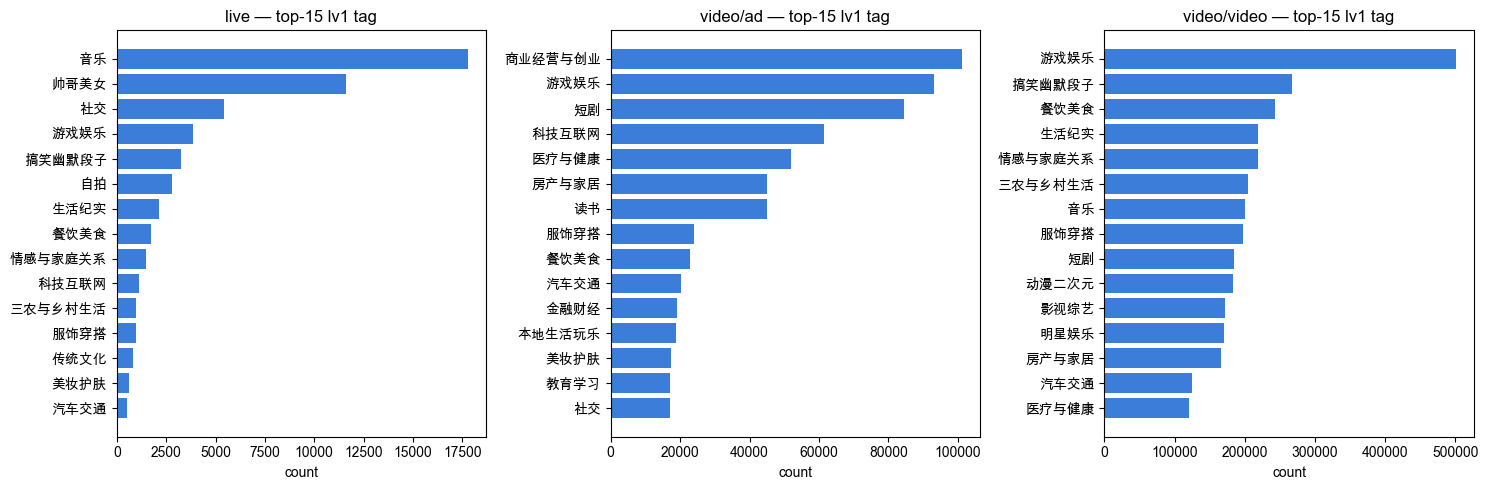

In [15]:
# lv1 top-15 的横向柱状图（每 domain 一个）
domains = sorted(tag_df['domain'].unique())
fig, axes = plt.subplots(1, len(domains), figsize=(5 * len(domains), 5), squeeze=False)
for i, d in enumerate(domains):
    sub = tag_df[tag_df.domain == d]
    tops = sub['lv1'].value_counts().head(15)
    ax = axes[0][i]
    ax.barh(tops.index[::-1], tops.values[::-1], color='#3b7dd8')
    ax.set_title(f'{d} — top-15 lv1 tag')
    ax.set_xlabel('count')
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_lv1_bars.png', dpi=110)
plt.show()

## §2.4.3 Tag ↔ SID 关联性（本 notebook 最核心）

把 `Pid2Tag` 和 `Pid2Sid` 按 `(pid, domain)` join，得到 `(pid, domain, tag_lv1, tag_lv2, tag_lv3, s_a, s_b, s_c)`。然后：

- 计算无条件熵 `H(s_a)`；
- 计算条件熵 `H(s_a | lv1)`, `H(s_a | lv12)`, `H(s_a | lv3)`；
- 信息增益 `IG = H(s_a) - H(s_a | tag)`。

**IG 越大 → tag 越能强预测 SID**：
- 若 `IG_lv3→s_a` 接近 `H(s_a)`，说明只要给出 lv3 tag，s_a 几乎确定 → 可以在 tag→SID 任务里做「tag-conditioned s_a mask」（constrained decoding）；
- 反之 IG 小说明 tag 对 SID 语义帮助有限，SID 关注的是「细粒度物料」而非「分类」。

> `Pid2Tag` 只 5.4M 行，扫 `Pid2Sid` 全量 3591M 用 pandas merge 会 OOM；这里用 **反向策略**：先把所有 tag 的 pid 加载成一个 `set`，然后流式扫 Sid 只保留在 tag pid 集合里的行。

In [16]:
def collect_sid_for_pids(sid_dir: Path, keep: dict):
    """keep: {domain: set(pid)}. 返回 df with columns pid,domain,s_a,s_b,s_c"""
    parts = []
    files = sorted(sid_dir.glob('part-*.parquet'))
    t0 = time.time()
    for i, fp in enumerate(files):
        if fp.stat().st_size == 0: continue
        pf = pq.ParquetFile(fp)
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=['pid', 'domain', 'sid_three'])
            df = tbl.to_pandas()
            keep_masks = []
            for d, pid_set in keep.items():
                sub = df[(df.domain == d) & (df.pid.isin(pid_set))]
                if len(sub):
                    keep_masks.append(sub)
            if keep_masks:
                parts.append(pd.concat(keep_masks, ignore_index=True))
        if (i + 1) % 30 == 0 or i == len(files) - 1:
            got = sum(len(p) for p in parts)
            print(f'  scanned {i+1}/{len(files)} sid parquet, kept={got:,}, elapsed {time.time()-t0:.1f}s')
    if not parts:
        return pd.DataFrame(columns=['pid', 'domain', 's_a', 's_b', 's_c'])
    out = pd.concat(parts, ignore_index=True)
    # 展开 sid_three
    triples = np.stack(out['sid_three'].values).astype(np.int32)  # (N, 3)
    out['s_a'] = triples[:, 0]; out['s_b'] = triples[:, 1]; out['s_c'] = triples[:, 2]
    return out.drop(columns=['sid_three'])


if USE_CACHE and CACHE_JOIN.with_suffix('.parquet').exists():
    print(f'[cache] loading {CACHE_JOIN.with_suffix(".parquet")} ...')
    joined = pd.read_parquet(CACHE_JOIN.with_suffix('.parquet'))
else:
    keep = {d: set(sub['pid'].astype(np.int64).tolist())
            for d, sub in tag_df.groupby('domain', sort=False)}
    print('pid sets built:', {d: len(v) for d, v in keep.items()})
    sid_hits = collect_sid_for_pids(PID2SID_DIR, keep)
    joined = tag_df.merge(sid_hits, on=['pid', 'domain'], how='inner')
    joined.to_parquet(CACHE_JOIN.with_suffix('.parquet'))
    print(f'[cache] saved to {CACHE_JOIN.with_suffix(".parquet")}')

print(f'\njoined shape: {joined.shape}')
print(joined[['domain', 'lv1', 'lv3', 's_a', 's_b', 's_c']].head(5).to_string(index=False))

[cache] loading /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/tag/_join_cache.parquet ...

joined shape: (5417279, 10)
domain   lv1    lv3  s_a  s_b  s_c
  live  游戏娱乐 传奇游戏解说 1790 1701 6278
  live    社交 地方同乡社交 4372 4885 7137
  live    音乐 土味音乐演唱 6475 3059 3676
  live 医疗与健康 女性健康养生 1860 7414 5956
  live    音乐 年轻女性唱歌 4372 3898  602


In [17]:
def entropy_from_series(series):
    counts = series.value_counts().values.astype(np.float64)
    p = counts / counts.sum()
    return float(-np.sum(p * np.log2(p + 1e-30)))


def cond_entropy(df, cond_col, target_col):
    total = len(df)
    H = 0.0
    for _, sub in df.groupby(cond_col, sort=False):
        p = len(sub) / total
        counts = sub[target_col].value_counts().values.astype(np.float64)
        pi = counts / counts.sum()
        H += p * float(-np.sum(pi * np.log2(pi + 1e-30)))
    return H


mi_rows = []
for domain, sub in joined.groupby('domain', sort=False):
    if len(sub) < 100:
        continue
    row = {'domain': domain, 'joined_rows': len(sub)}
    for tgt in ['s_a', 's_b', 's_c']:
        H_tgt = entropy_from_series(sub[tgt])
        H_lv1 = cond_entropy(sub, 'lv1', tgt)
        H_lv12 = cond_entropy(sub, 'lv12', tgt)
        H_lv3 = cond_entropy(sub, 'tag_lv3', tgt)
        row[f'H({tgt})'] = round(H_tgt, 3)
        row[f'IG_lv1→{tgt}'] = round(H_tgt - H_lv1, 3)
        row[f'IG_lv12→{tgt}'] = round(H_tgt - H_lv12, 3)
        row[f'IG_lv3→{tgt}'] = round(H_tgt - H_lv3, 3)
        row[f'IG_lv3→{tgt}_%'] = round((H_tgt - H_lv3) / max(1e-6, H_tgt) * 100, 2)
    mi_rows.append(row)

mi_df = pd.DataFrame(mi_rows)
mi_df.to_csv(OUT_DIR / 'tag_sid_mutual_info.csv', index=False)
print('saved:', OUT_DIR / 'tag_sid_mutual_info.csv')
mi_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/tag/tag_sid_mutual_info.csv


,domain,joined_rows,H(s_a),IG_lv1→s_a,IG_lv12→s_a,IG_lv3→s_a,IG_lv3→s_a_%,H(s_b),IG_lv1→s_b,IG_lv12→s_b,IG_lv3→s_b,IG_lv3→s_b_%,H(s_c),IG_lv1→s_c,IG_lv12→s_c,IG_lv3→s_c,IG_lv3→s_c_%
0,live,60231,5.322,0.887,1.247,1.711,32.15,6.461,0.650,1.080,1.651,25.55,8.300,0.699,1.238,1.979,23.85
1,video/ad,742085,8.560,2.671,3.442,4.065,47.49,9.098,1.285,1.917,2.540,27.91,10.199,0.970,1.561,2.196,21.54
2,video/video,4614963,9.493,2.769,3.615,4.440,46.78,9.483,1.223,1.827,2.608,27.50,10.382,0.755,1.219,1.937,18.65


## §2.4.4 每个 lv3 tag 最集中的 top-K s_a 桶

输出每个 lv3 tag 与其 top-3 关联的 s_a 桶（+ 集中度 = top1 s_a 占该 tag 的比例）。这是 tag-conditioned constrained decoding 的直接依据 —— 生成 s_a 时可以只在 top-K 里选。

In [18]:
for domain, sub in joined.groupby('domain', sort=False):
    if len(sub) < 100:
        continue
    rows = []
    for tag, g in sub.groupby('tag_lv3', sort=False):
        n = len(g)
        if n < 20:  # 太少的 tag 统计不置信
            continue
        vc = g['s_a'].value_counts()
        top3 = vc.head(3)
        rows.append({
            'tag_lv3':      tag,
            'n_pids':       n,
            'unique_s_a':   int(vc.size),
            'top1_s_a':     int(top3.index[0]),
            'top1_share':   round(top3.iloc[0] / n, 3),
            'top2_s_a':     int(top3.index[1]) if len(top3) > 1 else -1,
            'top2_share':   round(top3.iloc[1] / n, 3) if len(top3) > 1 else 0.0,
            'top3_s_a':     int(top3.index[2]) if len(top3) > 2 else -1,
            'top3_share':   round(top3.iloc[2] / n, 3) if len(top3) > 2 else 0.0,
            'top3_cum':     round(top3.sum() / n, 3),
        })
    df = pd.DataFrame(rows).sort_values(['n_pids'], ascending=False).reset_index(drop=True)
    safe = domain.replace('/', '_')
    df.to_csv(OUT_DIR / f'tag_lv3_top_sa_{safe}.csv', index=False)
    print(f'\n=== {domain}: {len(df)} lv3 tags analyzed ===')
    print(f'  top3 s_a 平均累积覆盖率: {df.top3_cum.mean():.2%}')
    print(f'  top1 s_a 平均集中度:    {df.top1_share.mean():.2%}')
    print(f'  saved  tag_lv3_top_sa_{safe}.csv')
    print('  --- 示例（按 pid 数量降序前 5 个 tag）---')
    print(df.head(5).to_string(index=False))


=== live: 252 lv3 tags analyzed ===
  top3 s_a 平均累积覆盖率: 57.62%
  top1 s_a 平均集中度:    31.42%
  saved  tag_lv3_top_sa_live.csv
  --- 示例（按 pid 数量降序前 5 个 tag）---
            tag_lv3  n_pids  unique_s_a  top1_s_a  top1_share  top2_s_a  top2_share  top3_s_a  top3_share  top3_cum
     音乐-音乐演唱-年轻女性唱歌    9912         280      6492       0.426      3367       0.118      1658       0.117     0.660
     音乐-音乐演唱-中年女性演唱    2761         142      6492       0.335      3367       0.204      1658       0.124     0.663
   帅哥美女-美女风采类型-气质美女    2438         156      6492       0.323      1658       0.182      3367       0.133     0.638
搞笑幽默段子-娱乐与表演艺术-直播整活    1957         145      3367       0.225      4372       0.193      2828       0.139     0.557
   帅哥美女-美女风采类型-性感美女    1887         111      6492       0.154      1658       0.137      1957       0.125     0.417

=== video/ad: 899 lv3 tags analyzed ===
  top3 s_a 平均累积覆盖率: 49.08%
  top1 s_a 平均集中度:    28.12%
  saved  tag_lv3_top_sa_video_ad.csv
  --- 示例（按 pi

## §2.4.5 结论 & 对 SFT 的直接指导

把关键结论抄进 `analysis/report.md`：

1. **tag_lv3 是标准 3 段结构**（`一级-二级-三级`），全域用同一套分类体系（这个可以从 `tag_hierarchy_stats.csv` 的 lv1 top-15 看出各 domain 的 lv1 大类是否重合）。
2. **tag 层数选取**：
   - 用 `IG_lv3→s_a_%` 决定 tag 是否强预测 SID；
   - 若 `IG_lv1→s_a_%` 已 > 30%（即 lv1 就能压缩 s_a 30%+ 的不确定性），"tag→SID"任务用 lv1 就够了，不需要 lv3；
   - 若必须用 lv3 才有强增益，则说明 lv1/lv2 太粗、不能给 s_a 提供足够 constrain，需要 lv3 才有意义。
3. **tag-conditioned constrained decoding**：`tag_lv3_top_sa_{domain}.csv` 里的 `top3_cum` 就是给定 tag 后限制 s_a 只在 top-3 桶里选的**理论 recall 上限**。若 > 90% 说明可行；若只有 50% 说明放太严会漏，需扩大到 top-10。
4. **tag 作为 hint 增强懂物料任务的 prompt**：例如 `"tag: 服饰穿搭-衣服单品测评与售卖-半身裙和连衣裙\n描述: xxx → SID"`，可显著降低 loss（因为 tag 已经 disambiguate 了大类）。
5. **兴趣演化任务**（懂用户 & 懂推荐）里的"主题采样"直接用 `top100_lv3_video_video.csv` 里的高频 lv3 tag —— 出现频次 > 一定阈值的 tag 才作为评测题目，避免长尾冷门题。

### 产出物清单（`analysis/outputs/tag/`）
- `tag_hierarchy_stats.csv` —— 每 domain 各层词表大小和发散度
- `top100_lv1_{domain}.csv` / `top100_lv12_{domain}.csv` / `top100_lv3_{domain}.csv`
- `top_lv1_bars.png`
- `tag_sid_mutual_info.csv` —— **本 notebook 的核心表**
- `tag_lv3_top_sa_{domain}.csv` —— tag → s_a 集中桶
- `_tag_cache.parquet`, `_join_cache.parquet`（供后续 notebook 复用）